In [161]:
import requests

OLLAMA_MODEL = "llama3.2:latest"

def llm_ollama(input_text, model=OLLAMA_MODEL):
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": [{"role": "user", "content": input_text}],
            "stream": False,
        },
        timeout=120,
    )
    response.raise_for_status()
    return response.json()["message"]["content"]

In [162]:
ollama_response = llm_ollama("Tell me a fun fact about Japan.")
print(ollama_response)

Here's one:

Did you know that Japan has a village called Ojika Island that is home to the oldest known vending machine in the world? It was installed in 1927 and still dispenses drinks, making it over 95 years old! The unique vending machine not only serves soda, water, and snacks but also offers umbrellas, hair dryers, and even toilet paper when you need them.

Isn't that fascinating?


In [163]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()
gemini_api_key = os.getenv("GEMINIE")

if not gemini_api_key:
    raise ValueError("Add GEMINIE to your .env file before running this cell.")

In [164]:
def llm_gemini(input_text, gemini_model="gemini-3.5-flash"):
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{gemini_model}:generateContent"
    response = requests.post(
        url,
        params={"key": gemini_api_key},
        json={"contents": [{"parts": [{"text": input_text}]}]},
        timeout=120,
    )
    response.raise_for_status()
    data = response.json()
    return data["candidates"][0]["content"]["parts"][0]["text"]

In [165]:
import requests

OLLAMA_MODEL = "llama3.2"

def llm_ollama(prompt):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False
        },
        timeout=120
    )

    response.raise_for_status()

    return response.json()["response"]

In [166]:
def score_article(article_text, topic):
    
    prompt = f"""
You are a political text analysis assistant.

Evaluate the sentiment expressed toward {topic}.

Return ONLY ONE NUMBER:

-2 = strongly negative
-1 = somewhat negative
0 = neutral
1 = somewhat positive
2 = strongly positive

Article:

{article_text[:3000]}
"""

    result = llm_ollama(prompt)

    try:
        return int(result.strip())
    except:
        return None

These are the keywords we previously selected for our news and Prime Minister Speech analysis

In [167]:
keywords = [
    "china",
    "nuclear",
    "immigration",
    "constitution",
    "deflation",
    "North Korea",
]

## Japan News Portion 

In [168]:
import pandas as pd

japan_english_filepath = "../../project/data/raw/japan_english_news_kaggle.csv"
JPnews_pd = pd.read_csv(japan_english_filepath, sep='\t') # set delimiter to tab
JPnews_pd.head(10)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...
5,Mainichi Shimbun,2021-12-09,News Navigator: What is 'Olympic diplomacy'?,NaN,The Mainichi Shimbun answers some common quest...
6,Mainichi Shimbun,2021-12-09,Editorial: Japan's main opposition CDP has tur...,NaN,"During party leaders' questions, which began a..."
7,Mainichi Shimbun,2021-12-10,News Navigator: How does the Japanese-develope...,NaN,The Mainichi Shimbun answers some common quest...
8,Mainichi Shimbun,2021-12-10,Editorial: Japan PM's response weak on 1 mil. ...,NaN,Calls have arisen for a review of a 1 million ...
9,Mainichi Shimbun,2021-12-11,Edging Toward Japan: Inspiration from Anpan Ma...,By,"Recently, my 9-year-old daughter mentioned in ..."


In [169]:
JPnews_pd["date"] = pd.to_datetime(JPnews_pd["date"])

## Attempting News Article Immigration Sentiment Analysis 

I will now be exploring the sentiment regarding immigration from the Japan Times, to do this, I have identified some key words that would be relevant to immigration to see how they are discussed in the news. 

In [170]:
immigration_terms = [
    "immigration",
    "immigrant",
    "migrant",
    "foreign worker",
    "foreign workers"
]

In [171]:
immigration_articles = JPnews_pd[
    JPnews_pd["text"].str.contains(
        "|".join(immigration_terms),
        case=False,
        na=False,
        regex=True
    )
]

print(len(immigration_articles))

279


In [172]:
for term in immigration_terms:
    count = JPnews_pd["text"].str.contains(
        term,
        case=False,
        na=False
    ).sum()

    print(f"{term}: {count}")

immigration: 182
immigrant: 72
migrant: 98
foreign worker: 17
foreign workers: 17


In [173]:
immigration_terms = [
    "immigration",
    "immigrant",
    "migrant"
]

pattern = "|".join(immigration_terms)

immigration_articles = JPnews_pd[
    JPnews_pd["text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )
]

print(len(immigration_articles))

264


In [174]:
immigration_articles[
    ["date", "title"]
].sample(
    20,
    random_state=42
)

,date,title
11045,2001-11-28,Four of nine rejected Afghans to be deported
31475,2005-01-01,Movie portrays struggle of ethnic Korean who b...
12115,2001-12-28,Peruvian hops fence out of airport
35702,2018-01-17,Trump camp seeks Supreme Court appeal of 'Drea...
15991,2002-05-16,Narita passengers lose no-fuss check-in service
16876,2002-06-12,Chinese teenager to remain in Japan
16521,2002-06-01,16 Britons denied entry in lead up to World Cup
28733,2003-07-28,Restart of Brazil migration marked
837,2001-01-25,Airport workers needed for more overseas flights
35816,2019-01-03,U.K. crime agency arrests two over arranging i...


In [175]:
sample = immigration_articles.sample(
    n=10,
    random_state=42
)

In [176]:
def analyze_article(article_text, topic):

    prompt = f"""
You are a political scientist.

Evaluate whether {topic} is portrayed positively or negatively.

SCORE:
-2 strongly negative
-1 somewhat negative
0 neutral
1 somewhat positive
2 strongly positive

Do NOT evaluate the tone of the writing.
Evaluate only how {topic} itself is portrayed.

Return EXACTLY:

SCORE:
FRAME:
KEY SENTENCE:
REASONING:

Article:
{article_text[:2500]}
"""

    return llm_ollama(prompt)

## Now applying this to the rest of the key words 

In [177]:
topics = {
    "Immigration": [
        "immigration",
        "immigrant",
        "migrant"
    ],
    "China": [
        "china",
        "chinese",
        "beijing"
    ],
    "Nuclear": [
        "nuclear",
        "nuclear power",
        "nuclear reactor",
        "fukushima"
    ],
    "Constitution": [
        "constitution",
        "constitutional",
        "article 9"
    ],
    "Deflation": [
        "deflation",
        "deflationary",
        "falling prices"
    ],
    "North Korea": [
        "north korea",
        "kim jong un",
        "nuclear weapons"
        "Democratic People's Republic of Korea"
        "DPRK"
    ]
}

In [178]:
for topic, keywords in topics.items():

    pattern = "|".join(keywords)

    count = JPnews_pd["text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()

    print(topic, count)

Immigration 264
China 2227
Nuclear 1007
Constitution 227
Deflation 245
North Korea 1138


In [179]:
def get_topic_articles(df, keywords):

    pattern = "|".join(keywords)

    return df[
        df["text"].str.contains(
            pattern,
            case=False,
            na=False,
            regex=True
        )
    ]

## Immigration

In [180]:
immigration_articles = get_topic_articles(
    JPnews_pd,
    topics["Immigration"]
)

sample = immigration_articles.sample(
    n=min(20, len(immigration_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
837,2001-01-25,Airport workers needed for more overseas flights
11015,2001-11-27,Afghans denied refugee status
11045,2001-11-28,Four of nine rejected Afghans to be deported
11591,2001-12-13,College targeted for visa violations
12115,2001-12-28,Peruvian hops fence out of airport
15991,2002-05-16,Narita passengers lose no-fuss check-in service
16450,2002-05-30,Two Afghan asylum seekers to be released
16521,2002-06-01,16 Britons denied entry in lead up to World Cup
16876,2002-06-12,Chinese teenager to remain in Japan
27525,2003-06-22,KANSAI: Who & What


In [181]:
sample = immigration_articles.sample(
    n=min(20, len(immigration_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Immigration"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

immigration_articles_df = pd.DataFrame(results)

immigration_articles_df["score"] = immigration_articles_df["analysis"].apply(extract_score)
immigration_articles_df["frame"] = immigration_articles_df["analysis"].apply(extract_frame)
immigration_articles_df["key_sentence"] = immigration_articles_df["analysis"].apply(extract_key_sentence)

print("Average Immigration sentiment:", immigration_articles_df["score"].mean())

Average Immigration sentiment: 0.05


In [182]:
immigration_articles_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
8,2001-01-25,Airport workers needed for more overseas flights,1,Immigration and customs staff,Justice Minister Masahiko Komura indicated Wed...
18,2001-11-27,Afghans denied refugee status,-1,Immigration policies and decisions,"""The applicants 'lack credibility as refugees ..."
0,2001-11-28,Four of nine rejected Afghans to be deported,-2,Deportation and rejection of Afghan refugees,"""four men will be deported to Afghanistan"""
13,2001-12-13,College targeted for visa violations,0,Immigration authorities searching a college of...,officials of the Tokyo Immigration Bureau cond...
2,2001-12-28,Peruvian hops fence out of airport,-2,The portrayal of immigration as a violation of...,"""The man, 23, was deported Dec. 18 on suspicio..."
4,2002-05-16,Narita passengers lose no-fuss check-in service,-1,Discontinuation of immigration services,"“From a rational standpoint, we have decided t..."
15,2002-05-30,Two Afghan asylum seekers to be released,1,Immigration as a form of asylum seeking protec...,"""The two will be released after their supporte..."
6,2002-06-01,16 Britons denied entry in lead up to World Cup,-2,Negative depiction of immigration in Japan,"""Japanese immigration authorities have turned ..."
5,2002-06-12,Chinese teenager to remain in Japan,-2,Immigration policies and their impact on indiv...,"""his family will be deported immediately"""
10,2003-06-22,KANSAI: Who & What,2,Immigration,Specialists will offer advice on problems that...


## China

In [183]:
china_articles = get_topic_articles(
    JPnews_pd,
    topics["China"]
)

sample = china_articles.sample(
    n=min(20, len(china_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
1297,2001-02-06,Poor seaweed crop from Ariake Sea causes price...
2429,2001-03-07,Don't throw in the towel on free trade
3678,2001-04-12,A 'cold war' in the making
4179,2001-04-26,China postpones legislative chief's visit to J...
7449,2001-08-14,Koizumi visits Yasukuni Shrine
8911,2001-09-26,Asian Youth Orchestra brings vigor and virtuosity
10331,2001-11-08,"Japan, China trade row remains at stalemate"
12833,2002-01-22,Coast guard vessels to mount 30mm machine guns
13734,2002-02-21,Kinki mirror identified as being made in China
15810,2002-05-11,Tour body offers phrase book in four languages


In [184]:
sample = china_articles.sample(
    n=min(20, len(china_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "China"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

china_articles_df = pd.DataFrame(results)

china_articles_df["score"] = china_articles_df["analysis"].apply(extract_score)
china_articles_df["frame"] = china_articles_df["analysis"].apply(extract_frame)
china_articles_df["key_sentence"] = china_articles_df["analysis"].apply(extract_key_sentence)

print("Average China sentiment:", china_articles_df["score"].mean())

Average China sentiment: -0.4


In [185]:
china_articles_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
0,2001-02-06,Poor seaweed crop from Ariake Sea causes price...,-1,China is mentioned as part of a discussion abo...,The project is allegedly reducing the volume o...
12,2001-03-07,Don't throw in the towel on free trade,-2,The article portrays China as a threat to Japan,"""Towel imports, about 80 percent of them from ..."
10,2001-04-12,A 'cold war' in the making,-2,The article portrays China negatively as part ...,A manifestation of the Sino-American “cold war”
3,2001-04-26,China postpones legislative chief's visit to J...,-1,Diplomatic relations,China on Wednesday said it will postpone a pla...
18,2001-08-14,Koizumi visits Yasukuni Shrine,-2,China,Noting that World War II Class A war criminals...
1,2001-09-26,Asian Youth Orchestra brings vigor and virtuosity,2,The Asian Youth Orchestra is portrayed as a sy...,culturally by the vibrant unity of performers ...
8,2001-11-08,"Japan, China trade row remains at stalemate",0,neutral article about a trade dispute between ...,None provided (the article is too short)
13,2002-01-22,Coast guard vessels to mount 30mm machine guns,-2,The East China Sea,Japan Coast Guard will install long-range mach...
4,2002-02-21,Kinki mirror identified as being made in China,2,China as a cultural and historical hub,The mirror discovered at the Morio mound was d...
5,2002-05-11,Tour body offers phrase book in four languages,0,KEY SENTENCE,


## Nuclear

In [186]:
nuclear_articles = get_topic_articles(
    JPnews_pd,
    topics["Nuclear"]
)

sample = nuclear_articles.sample(
    n=min(20, len(nuclear_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
2727,2001-03-17,Uwajima petition calls for ship to be raised
4926,2001-05-17,Three teens killed in head-on crash
13550,2002-02-14,NGO raps use of cell phones at Oze
16682,2002-06-06,Fukuda tells Diet government is not rethinking...
17679,2002-07-06,Atomic plants gauge plane crash odds
19636,2002-09-07,City passes resolution against nuke plan
19800,2002-09-12,Brave trip to settle the past
22228,2003-01-04,Pressure called for
23670,2003-02-16,Cabral first at World Cup meet
24024,2003-02-27,Agency calls for repair of reactor cracks


In [187]:
sample = nuclear_articles.sample(
    n=min(20, len(nuclear_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Nuclear"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

nuclear_articles_df = pd.DataFrame(results)

nuclear_articles_df["score"] = nuclear_articles_df["analysis"].apply(extract_score)
nuclear_articles_df["frame"] = nuclear_articles_df["analysis"].apply(extract_frame)
nuclear_articles_df["key_sentence"] = nuclear_articles_df["analysis"].apply(extract_key_sentence)

print("Average Nuclear sentiment:", nuclear_articles_df["score"].mean())

Average Nuclear sentiment: -0.2


In [188]:
nuclear_articles_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
9,2001-03-17,Uwajima petition calls for ship to be raised,2,Nuclear power,"""the Ehime Maru to be raised"""
19,2001-05-17,Three teens killed in head-on crash,0,KEY SENTENCE,
14,2002-02-14,NGO raps use of cell phones at Oze,0,None provided,None provided
18,2002-06-06,Fukuda tells Diet government is not rethinking...,0,Nuclear,None
8,2002-07-06,Atomic plants gauge plane crash odds,0,Nuclear power plants,None provided in the excerpt
4,2002-09-07,City passes resolution against nuke plan,-1,Nuclear power plants,asking Tokyo Electric Power Co. and the centra...
11,2002-09-12,Brave trip to settle the past,-2,Nuclear weapons and program,"""North Korea’s suspected nuclear weapons program"""
13,2003-01-04,Pressure called for,0,Nuclear power plant development,"""to give up its nuclear development program"""
3,2003-02-16,Cabral first at World Cup meet,0,KEY SENTENCE,
7,2003-02-27,Agency calls for repair of reactor cracks,0,Nuclear reactors,"""Cracked pipes in nuclear reactors owned by th..."


^ this does not make sense with the key sentence. figure out. nuclear should be more relevant around 2011. 

## Deflation

In [189]:
Deflation_articles = get_topic_articles(
    JPnews_pd,
    topics["Deflation"]
)

sample = Deflation_articles.sample(
    n=min(20, len(Deflation_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
2950,2001-03-23,Hayami lauds BOJ's strategy
3584,2001-04-10,Reasons to thank Mr. Mori
7146,2001-08-05,Ignite Japan's service sector
8879,2001-09-26,Firms turn to time-sharing in bid to increase ...
12548,2002-01-13,Takenaka suggests inflation targeting to fight...
13569,2002-02-15,Small companies set for loan repayment boost
14250,2002-03-14,World Bank sees 1.5% fall in GDP
16946,2002-06-14,Koizumi proposes retroactive tax breaks
20378,2002-09-30,Japan as a 'banana republic'?
21224,2002-11-14,SEC's post-Enron reforms pose challenge for Ja...


In [190]:
sample = Deflation_articles.sample(
    n=min(20, len(Deflation_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Deflation"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

deflation_articles_df = pd.DataFrame(results)

deflation_articles_df["score"] = deflation_articles_df["analysis"].apply(extract_score)
deflation_articles_df["frame"] = deflation_articles_df["analysis"].apply(extract_frame)
deflation_articles_df["key_sentence"] = deflation_articles_df["analysis"].apply(extract_key_sentence)

print("Average Deflation sentiment:", deflation_articles_df["score"].mean())

Average Deflation sentiment: -0.2


In [191]:
deflation_articles_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
1,2001-03-23,Hayami lauds BOJ's strategy,2,The effectiveness of deflation in lowering int...,Bank of Japan Gov. Masaru Hayami said Thursday...
8,2001-04-10,Reasons to thank Mr. Mori,1,Deflation is mentioned as a consequence of the...,"""During Mori’s tenure, stock prices plunged an..."
17,2001-08-05,Ignite Japan's service sector,-1,Deflation is portrayed as a problem to be cured,"""But his prescription is incomplete. Without a..."
0,2001-09-26,Firms turn to time-sharing in bid to increase ...,-1,Deflation is portrayed as a problem that busin...,"""Amid record-high unemployment and spiraling d..."
10,2002-01-13,Takenaka suggests inflation targeting to fight...,2,Economic policy,"""We could draw a lesson from the experiences o..."
18,2002-02-15,Small companies set for loan repayment boost,0,None provided,None provided
14,2002-03-14,World Bank sees 1.5% fall in GDP,-1,Economic indicator,"""due to persistent deflation"""
9,2002-06-14,Koizumi proposes retroactive tax breaks,2,Deflation as a challenge to be addressed,Prime Minister Junichiro Koizumi on Thursday p...
12,2002-09-30,Japan as a 'banana republic'?,-2,Deflation is portrayed as a significant problem,"""that price deflation is public enemy No. 1 fo..."
7,2002-11-14,SEC's post-Enron reforms pose challenge for Ja...,-1,Deflation,"""long-term economic deterioration and deflation"""


## North Korea

In [192]:
north_korea_articles = get_topic_articles(
    JPnews_pd,
    topics["North Korea"]
)

sample = north_korea_articles.sample(
    n=min(20, len(north_korea_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
4458,2001-05-03,"Peace, security and missile defense"
6017,2001-06-15,Korean summit fails to meet expectations
7883,2001-08-25,Why Dear Leader isn't going to Seoul
17528,2002-07-02,Koizumi backs Kim's stance on shootout
19390,2002-08-31,Koizumi to visit Pyongyang Sept. 17
19964,2002-09-17,Breaking down the barriers
20962,2002-11-07,Activist expelled by China returns home
21307,2002-11-17,Ishihara is 'war maniac': Pyongyang
22478,2003-01-12,Japan asks U.N. to ban abductions
23630,2003-02-15,North Korea vs. the world


In [193]:
sample = north_korea_articles.sample(
    n=min(20, len(north_korea_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "North Korea"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

north_korea_articles_df = pd.DataFrame(results)

north_korea_articles_df["score"] = north_korea_articles_df["analysis"].apply(extract_score)
north_korea_articles_df["frame"] = north_korea_articles_df["analysis"].apply(extract_frame)
north_korea_articles_df["key_sentence"] = north_korea_articles_df["analysis"].apply(extract_key_sentence)

print("Average North Korea sentiment:", north_korea_articles_df["score"].mean())

Average North Korea sentiment: -1.35


In [194]:
north_korea_articles_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
7,2001-05-03,"Peace, security and missile defense",-2,North Korea is portrayed as a,"""...a 'rogue nation', such as North Korea or I..."
11,2001-06-15,Korean summit fails to meet expectations,-2,North Korea is portrayed as uncertain,"""the process was put on hold by the North pend..."
5,2001-08-25,Why Dear Leader isn't going to Seoul,-2,North Korea,"""All contacts have stopped."""
9,2002-07-02,Koizumi backs Kim's stance on shootout,-2,Negative portrayal of North Korea,"""North Korea started the recent maritime shoot..."
2,2002-08-31,Koizumi to visit Pyongyang Sept. 17,2,Diplomatic visit by a Japanese Prime Minister,"""Prime Minister Junichiro Koizumi will make a ..."
4,2002-09-17,Breaking down the barriers,2,North Korea is mentioned as a contrast to the ...,"""Ironically, the continuing standoff between N..."
19,2002-11-07,Activist expelled by China returns home,-2,News article about a Japanese NGO official bei...,None provided in the text snippet
16,2002-11-17,Ishihara is 'war maniac': Pyongyang,-2,North Korea,"""an ultraright reactionary of Japan"" and ""a me..."
6,2003-01-12,Japan asks U.N. to ban abductions,-2,North Korea as a country responsible for abduc...,"""the abductions of Japanese nationals by North..."
18,2003-02-15,North Korea vs. the world,-2,North Korea is portrayed as a rogue state that...,"""North Korea has always played fast and loose ..."


## Summarizing Findings

In [195]:
news_summary = pd.DataFrame({
    "Topic": [
        "Immigration",
        "China",
        "Nuclear",
        "Deflation",
        "North Korea"
    ],
    "Average Sentiment": [
        immigration_articles_df["score"].mean(),
        china_articles_df["score"].mean(),
        nuclear_articles_df["score"].mean(),
        deflation_articles_df["score"].mean(),
        north_korea_articles_df["score"].mean()
    ]
})

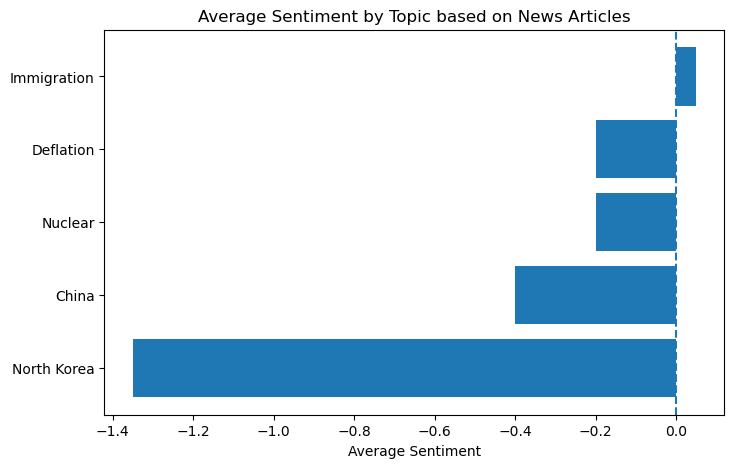

In [196]:
import matplotlib.pyplot as plt

news_summary = news_summary.sort_values("Average Sentiment")

plt.figure(figsize=(8,5))

plt.barh(
    news_summary["Topic"],
    news_summary["Average Sentiment"]
)

plt.axvline(x=0, linestyle="--")

plt.xlabel("Average Sentiment")
plt.title("Average Sentiment by Topic based on News Articles")

plt.show()

In [197]:
china_text = "\n\n".join(
    china_df["analysis"].tolist()
)

In [198]:
prompt = f"""
You are a political science researcher.

Review these article analyses about China.

Summarize:

1. Overall sentiment
2. Most common frames
3. Recurring themes
4. 3-5 sentence summary

Analyses:

{china_text[:12000]}
"""

print(llm_ollama(prompt))

Based on the article analyses, here are the summaries:

1. Overall sentiment:
The overall sentiment of these articles is neutral with a leaning towards caution and restraint when discussing China. While some speeches express strong opposition to China's actions, others focus on promoting cooperation and diplomacy.

2. Most common frames:
The most common frames used in these articles are Security (5 scores), Diplomatic (4 scores), Administrative (3 scores), and No clear policy frame mentioned regarding China (4 scores).

3. Recurring themes:
Recurring themes include Japan's security concerns, its commitment to international cooperation, and the government's stance on issues related to global stability and peace.

4. 3-5 sentence summary:

The articles summarize speeches by Japanese officials where China is discussed in various contexts. Scores range from strongly supportive (-2) to no mention of China (0). The most common frame used for these scores is Security, reflecting Japan's conce

In [199]:
topic_dfs = {
    "Immigration": immigration_articles_df,
    "China": china_articles_df,
    "Nuclear": nuclear_articles_df,
    "Deflation": deflation_articles_df,
    "North Korea": north_korea_articles_df
}

In [200]:
for topic, df in topic_dfs.items():

    text = "\n\n".join(
        df["analysis"].tolist()
    )

    prompt = f"""
Summarize the findings for {topic}.

Include:
- overall sentiment
- dominant frames
- recurring themes

Keep to 4-5 sentences.
    
{text[:12000]}
"""

    summary = llm_ollama(prompt)

    print("="*80)
    print(topic)
    print(summary)


Immigration
Here is a summary of the findings for Immigration:

Overall sentiment: The overall sentiment towards immigration is mixed, with some frames portraying it positively (e.g., as a beneficial program, a humanitarian issue) while others depict it negatively (e.g., as a violation of laws, a threat to national security).

Dominant frames: Negative and positive frames are present, but the negative frames dominate. The most common negative frames include deportation, rejection, and profiling.

Recurring themes: The recurring theme in negative frames is that immigration policies prioritize enforcement over human rights or compassion. Positive frames emphasize the benefits of immigration, such as cultural exchange and education, or portray it as a humanitarian issue.
China
Here are the summaries:

1. SCORE: -1 somewhat negative
FRAME: The project is allegedly reducing the volume of fresh seawater from the East China Sea.
REASONING: This sentence implies that an environmental issue (re

## Speech Sentiment Analysis

In [201]:
import pandas as pd

speech_filepath = "../data/clean/pm_speeches_en.csv"

speech_df = pd.read_csv(
    speech_filepath,
    index_col="date",
    parse_dates=True
)

speech_df.head()

,title,place,source,text
date,,,,
1951-09-07,Prime Minister Shigeru Yoshida's Speech at the...,San Francisco,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1977-08-18,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,Manila,The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
1988-05-04,Statement by Prime Minister Takeshita on the O...,London,Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
1991-05-03,Policy Speech by Prime Minister Toshiki Kaifu ...,Singapore,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
1991-05-27,Address by Prime Minister Toshiki Kaifu at the...,"Kyoto, Japan","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


In [202]:
for topic, keywords in topics.items():

    pattern = "|".join(keywords)

    count = JPspeech_pd["date,title,place,source,text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()

    print(topic, count)

Immigration 26
China 210
Nuclear 577
Constitution 40
Deflation 30
North Korea 161


In [203]:
def analyze_speech(speech_text, topic):

    prompt = f"""
You are a political scientist analyzing Japanese Prime Minister speeches.

Your task is to evaluate the government's stance toward {topic}.

Do NOT evaluate the emotional tone or writing style.
Instead, determine whether the Prime Minister presents {topic} as something the government supports, opposes, or discusses neutrally.

SCORE:
-2 Strongly opposed
-1 Somewhat opposed
0 Neutral, descriptive, or no clear position
1 Somewhat supportive
2 Strongly supportive

If {topic} is only briefly mentioned or lacks a clear policy position, assign a score of 0.

FRAME:
Identify the primary policy frame used to discuss {topic}. Choose the single best frame, such as:
- Economic
- Security
- Diplomatic
- Humanitarian
- Demographic
- Labor Market
- Administrative
- Environmental
- Other

KEY SENTENCE:
Quote the single sentence that best supports your evaluation.

REASONING:
Briefly explain why you assigned the score and frame.

Speech:
{speech_text[:2500]}

Return EXACTLY:

SCORE:
FRAME:
KEY SENTENCE:
REASONING:
"""

    return llm_ollama(prompt)

In [204]:
def get_topic_speeches(df, keywords):
    pattern = "|".join(keywords)
    return df[df["text"].str.contains(pattern, case=False, na=False)]

## Speech Immigration

In [205]:
immigration_speeches = get_topic_speeches(
    speech_df,
    topics["Immigration"]
)

sample = immigration_speeches.sample(
    n=min(20, len(immigration_speeches)),
    random_state=42
)

sample.sort_index()

,title,place,source,text
date,,,,
2006-07-21,Statement by Prime Minister Junichiro Koizumi ...,NaN,"Cabinet Public Affairs Office, Cabinet Secreta...",With regard to the emigration programme to the...
2008-05-28,"Address by H.E. Mr. Yasuo Fukuda, Prime Minist...",Yokohama,Ministry of Foreign Affairs of Japan,"Your Majesty, Your Excellencies, Distinguished..."
2015-09-29,Address by Prime Minister Shinzo Abe at the Se...,New York,Prime Minister of Japan and His Cabinet,"Mr. President, Ladies and Gentlemen,\n\nThe Un..."
2016-09-19,Statement by Prime Minister Shinzo Abe at the ...,United Nations Trusteeship Council Chamber in ...,Prime Minister of Japan and His Cabinet,"Excellencies,\n\nToday the world faces an unpr..."
2016-09-20,Statement by Prime Minister Shinzo Abe at the ...,United Nations Trusteeship Council Chamber in ...,Prime Minister of Japan and His Cabinet,"Excellencies,\n\nLadies and Gentlemen,\n\nRefu..."
2023-11-03,"Contributed Article ""Celebrating our 'special ...",NaN,"Cabinet Public Affairs Office, Cabinet Secreta...","As Prime Minister of Japan, I extend warm gree..."
2023-11-14,"Contributed Article ""Why APEC in S.F. carries ...",NaN,"Cabinet Public Affairs Office, Cabinet Secreta...","As prime minister of Japan, I was delighted to..."
2024-01-16,Video Message by Prime Minister Kishida at the...,NaN,"Cabinet Public Affairs Office, Cabinet Secreta...","I am KISHIDA Fumio, Prime Minister of Japan.\n..."
2024-05-04,Speech by Prime Minister KISHIDA Fumio on Japa...,NaN,"Cabinet Public Affairs Office, Cabinet Secreta...",1. A new pathway for Japan and Latin America a...


In [206]:
sample = immigration_speeches.sample(
    n=min(20, len(immigration_speeches)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_speech(
        row["text"],
        "Immigration"
    )

    results.append({
       "date": row.name,
        "title": row["title"],
        "analysis": analysis
    })

immigration_speech_df = pd.DataFrame(results)

immigration_speech_df["score"] = immigration_speech_df["analysis"].apply(extract_score)
immigration_speech_df["frame"] = immigration_speech_df["analysis"].apply(extract_frame)
immigration_speech_df["key_sentence"] = immigration_speech_df["analysis"].apply(extract_key_sentence)

print("Average Immigration sentiment:", immigration_speech_df["score"].mean())

Average Immigration sentiment: 0.7857142857142857


In [207]:
immigration_speech_df.reset_index()[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
2,2006-07-21,Statement by Prime Minister Junichiro Koizumi ...,0,Administrative,"""The Government has judged, in full considerat..."
7,2008-05-28,"Address by H.E. Mr. Yasuo Fukuda, Prime Minist...",0,None,None
6,2015-09-29,Address by Prime Minister Shinzo Abe at the Se...,2,Humanitarian,"""Japan will further enhance its assistance for..."
12,2016-09-19,Statement by Prime Minister Shinzo Abe at the ...,2,Demographic,"""One of the characteristics of Japan's assista..."
9,2016-09-20,Statement by Prime Minister Shinzo Abe at the ...,2,Humanitarian,"""Japan will make efforts to ensure regional pe..."
4,2023-11-03,"Contributed Article ""Celebrating our 'special ...",0,None,There is no sentence that supports an evaluati...
13,2023-11-14,"Contributed Article ""Why APEC in S.F. carries ...",0,None,None
10,2024-01-16,Video Message by Prime Minister Kishida at the...,1,Demographic,"""Thanks to Japanese immigrants to Brazil, and ..."
5,2024-05-04,Speech by Prime Minister KISHIDA Fumio on Japa...,2,Demographic,"""After the passage of more than a century of h..."
0,2024-11-14,Contributed Article by Prime Minister Ishiba t...,1,Demographic,"""I am grateful that Peruvian society has welco..."


## China

In [208]:
china_speeches = get_topic_speeches(
    speech_df,
    topics["China"]
)

sample = china_speeches.sample(
    n=min(20, len(china_speeches)),
    random_state=42
)

sample.sort_index()

,title,place,source,text
date,,,,
1951-09-07,Prime Minister Shigeru Yoshida's Speech at the...,San Francisco,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1992-01-17,Policy Speech by Prime Minister Kiichi Miyazaw...,Seoul,"DIPLOMATIC BLUEBOOK 1992, Japan's Diplomatic A...","The Honorable Park Jyun Kyu,\n\nRespected Spea..."
2008-01-26,"Special Address by Yasuo Fukuda, Prime Ministe...",Davos,Ministry of Foreign Affairs of Japanese,1. Introduction\n\nFounder and Executive Chair...
2008-09-25,ADDRESS BY H.E. MR. TARO ASO PRIME MINISTER OF...,NEW YORK,Ministry of Foreign Affairs of Japan,"Mr. President,\n\nDistinguished delegates,\n\n..."
2011-09-23,ADDRESS BY H.E. MR. YOSHIHIKO NODA PRIME MINIS...,NaN,Prime Minister of JAPAN and His Cabinet,"Mr. President,\n\nDistinguished Delegates,\n\n..."
2013-02-22,Japan is Back (Shinzo Abe's speech at CSIS),Center for Strategic and International Studies...,Ministry of Foreign Affairs of Japan,"Thank you very much, Dr. Hamre, for your warm ..."
2014-01-22,"A New Vision from a New Japan, World Economic ...","Congress Centre, Davos, Switzerland",Prime Minister of Japan and His Cabinet,"-Japan was at dusk?-\n\nThank you, Professor S..."
2014-05-06,Japan and NATO As âNatural Partnersâ - Spe...,"OECD Headquarters, Paris, France",Prime Minister of Japan and His Cabinet,1. Introduction: Natural partners\n\nSecretary...
2015-09-27,Speech by Prime Minister Shinzo Abe at Global ...,NaN,Prime Minister of Japan and His Cabinet,"Since I became Prime Minister of Japan, the fu..."


In [209]:
sample = china_speeches.sample(
    n=min(20, len(china_speeches)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_speech(
        row["text"],
        "China"
    )

    results.append({
       "date": row.name,
        "title": row["title"],
        "analysis": analysis
    })

china_speech_df = pd.DataFrame(results)

china_speech_df["score"] = china_speech_df["analysis"].apply(extract_score)
china_speech_df["frame"] = china_speech_df["analysis"].apply(extract_frame)
china_speech_df["key_sentence"] = china_speech_df["analysis"].apply(extract_key_sentence)

print("Average China sentiment:", china_speech_df["score"].mean())

Average China sentiment: 0.0


In [210]:
china_speech_df.reset_index()[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
4,1951-09-07,Prime Minister Shigeru Yoshida's Speech at the...,-1,Diplomatic,"""With respect to the Kuriles and South Sakhali..."
15,1992-01-17,Policy Speech by Prime Minister Kiichi Miyazaw...,0,Diplomatic,"""Today they must all rally around the United N..."
8,2008-01-26,"Special Address by Yasuo Fukuda, Prime Ministe...",0,Economic,"""This, I would argue, is the root cause of the..."
14,2008-09-25,ADDRESS BY H.E. MR. TARO ASO PRIME MINISTER OF...,0,None,None
16,2011-09-23,ADDRESS BY H.E. MR. YOSHIHIKO NODA PRIME MINIS...,0,None,None
1,2013-02-22,Japan is Back (Shinzo Abe's speech at CSIS),2,Diplomatic,"""Japan must work even more closely with the U...."
5,2014-01-22,"A New Vision from a New Japan, World Economic ...",0,None,None (there is no single sentence that clearly...
17,2014-05-06,Japan and NATO As âNatural Partnersâ - Spe...,0,Diplomatic,"""Japan will commit even more strongly than eve..."
11,2015-09-27,Speech by Prime Minister Shinzo Abe at Global ...,0,None,There is no mention of China in the speech.
6,2016-09-09,Statement by the Prime Minister of Japan (on t...,-2,Security,"""The nuclear test by North Korea is a clear an..."


## Nuclear

In [211]:
nuclear_speeches = get_topic_speeches(
    speech_df,
    topics["Nuclear"]
)

sample = nuclear_speeches.sample(
    n=min(20, len(nuclear_speeches)),
    random_state=42
)

sample.sort_index()

,title,place,source,text
date,,,,
2009-12-29 00:00:00,"Remarks by H.E. Dr. Yukio Hatoyama, Prime Mini...",New Delhi,Ministry of Foreign Affairs of Japan,Your Excellency Prime Minister Dr. Manmohan Si...
2010-09-24 00:00:00,ADDRESS BY H.E. MR. NAOTO KAN PRIME MINISTER O...,New York,Prime Minister of JAPAN and His Cabinet,"Mr. President,\n\nDistinguished Delegates,\n\n..."
2011-03-11 16:55:00,Statement by Prime Minister Naoto Kan on Tohok...,NaN,Prime Minister of JAPAN and His Cabinet,"My fellow citizens, as you are already aware f..."
2011-04-15 00:00:00,Japan's road to recovery and rebirth (Op-ed by...,NaN,Prime Minister of JAPAN and His Cabinet,"On March 11, Japan was hit by one of the most ..."
2011-09-22 00:00:00,"Address by H.E. Mr. Yoshihiko Noda, Prime Mini...",New York,Prime Minister of JAPAN and His Cabinet,"Mr. Secretary-General of the united Nations,\n..."
2011-12-28 00:00:00,Address by Prime Minister Noda at the invitati...,"Taj Palace Hotel, New Delhi, India",Prime Minister of JAPAN and His Cabinet,1. Introduction\n\nGood afternoon everyone. I ...
2012-12-26 00:00:00,Statement by Prime Minister Yoshihiko Noda upo...,NaN,Prime Minister of Japan and His Cabinet,"Today, my Cabinet and I have resigned en masse..."
2013-09-26 00:00:00,"Address by Prime Minister Shinzo Abe, at The S...",New York,Prime Minister of Japan and His Cabinet,"Mr. President, Mr. Secretary General, fellow d..."
2016-03-11 00:00:00,Address by Prime Minister Shinzo Abe to the Me...,NaN,Prime Minister of Japan and His Cabinet,In the gracious presence of Their Majesties th...


In [212]:
sample = nuclear_speeches.sample(
    n=min(20, len(nuclear_speeches)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_speech(
        row["text"],
        "Nuclear"
    )

    results.append({
       "date": row.name,
        "title": row["title"],
        "analysis": analysis
    })

nuclear_speech_df = pd.DataFrame(results)

nuclear_speech_df["score"] = nuclear_speech_df["analysis"].apply(extract_score)
nuclear_speech_df["frame"] = nuclear_speech_df["analysis"].apply(extract_frame)
nuclear_speech_df["key_sentence"] = nuclear_speech_df["analysis"].apply(extract_key_sentence)

print("Average Nuclear sentiment:", nuclear_speech_df["score"].mean())

Average Nuclear sentiment: 0.55


In [213]:
nuclear_speech_df.reset_index()[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
18,2009-12-29 00:00:00,"Remarks by H.E. Dr. Yukio Hatoyama, Prime Mini...",0,None,There is no clear mention or discussion about ...
14,2010-09-24 00:00:00,ADDRESS BY H.E. MR. NAOTO KAN PRIME MINISTER O...,0,None listed,"""Japan attaches a great importance to achievin..."
5,2011-03-11 16:55:00,Statement by Prime Minister Naoto Kan on Tohok...,0,Administrative,"""At present we have no reports of any radioact..."
0,2011-04-15 00:00:00,Japan's road to recovery and rebirth (Op-ed by...,1,Security,"""We have also received full U.S. support in re..."
10,2011-09-22 00:00:00,"Address by H.E. Mr. Yoshihiko Noda, Prime Mini...",0,Neutral,"""Since struck by a massive earthquake and tsun..."
3,2011-12-28 00:00:00,Address by Prime Minister Noda at the invitati...,0,None,None
12,2012-12-26 00:00:00,Statement by Prime Minister Yoshihiko Noda upo...,0,None,There is no single sentence that clearly suppo...
1,2013-09-26 00:00:00,"Address by Prime Minister Shinzo Abe, at The S...",0,Administrative,"""We feel righteous indignation about innocent ..."
4,2016-03-11 00:00:00,Address by Prime Minister Shinzo Abe to the Me...,2,Security,"""we will ceaselessly review disaster-preventio..."
17,2017-09-03 00:00:00,Statement by Prime Minister Shinzo Abe (on the...,2,Security,"""North Korea's nuclear and missile development..."


## Deflation

In [214]:
Deflation_speeches = get_topic_speeches(
    speech_df,
    topics["Deflation"]
)

sample = Deflation_speeches.sample(
    n=min(20, len(Deflation_speeches)),
    random_state=42
)

sample.sort_index()

,title,place,source,text
date,,,,
2008-05-22,"When the Pacific Ocean Becomes an ""Inland Sea""...",Tokyo,Ministry of Foreign Affairs of Japanese,"Excellencies,\n\nDistinguished guests,\n\nLadi..."
2012-02-17,Transcript of Video Message from Prime Ministe...,NaN,Prime Minister of JAPAN and His Cabinet,"People of Japan, I am Prime Minister Yoshihiko..."
2013-01-01,New Yearâs Reflection by Prime Minister Shin...,NaN,Prime Minister of Japan and His Cabinet,I would like to wish all of you a very Happy N...
2013-02-22,Japan is Back (Shinzo Abe's speech at CSIS),Center for Strategic and International Studies...,Ministry of Foreign Affairs of Japan,"Thank you very much, Dr. Hamre, for your warm ..."
2013-06-05,Speech on the Third Round of Policies under th...,NaN,Prime Minister of Japan and His Cabinet,1. Towards a sound growth cycle\n\nThe Japanes...
2013-07-26,"Japan and ASEAN, Always in Tandem:Towards a Mo...","Ritz Carlton, Singapore",Ministry of Foreign Affairs of Japan,"Introduction\n\nDeputy Prime Minister,\n\nDepu..."
2014-01-22,"A New Vision from a New Japan, World Economic ...","Congress Centre, Davos, Switzerland",Prime Minister of Japan and His Cabinet,"-Japan was at dusk?-\n\nThank you, Professor S..."
2014-04-17,Keynote Address by Prime Minister Abe at The E...,NaN,Prime Minister of Japan and His Cabinet,"Towards a Japan, at ease, that relishes change..."
2014-05-01,Redefining Japan-UK Relations-Remarks by Prime...,NaN,Prime Minister of Japan and His Cabinet,"Good evening, ladies and gentlemen. I am Shinz..."


In [215]:
sample = Deflation_speeches.sample(
    n=min(20, len(Deflation_speeches)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_speech(
        row["text"],
        "Deflation"
    )

    results.append({
       "date": row.name,
        "title": row["title"],
        "analysis": analysis
    })

Deflation_speech_df = pd.DataFrame(results)

Deflation_speech_df["score"] = Deflation_speech_df["analysis"].apply(extract_score)
Deflation_speech_df["frame"] = Deflation_speech_df["analysis"].apply(extract_frame)
Deflation_speech_df["key_sentence"] = Deflation_speech_df["analysis"].apply(extract_key_sentence)

print("Average Deflation sentiment:", Deflation_speech_df["score"].mean())

Average Deflation sentiment: 1.0


In [216]:
Deflation_speech_df.reset_index()[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
0,2008-05-22,"When the Pacific Ocean Becomes an ""Inland Sea""...",0,None,None
1,2012-02-17,Transcript of Video Message from Prime Ministe...,0,Economic,"""The foundation of Japan's social security sys..."
9,2013-01-01,New Yearâs Reflection by Prime Minister Shin...,1,Economic,"""For Japan, the most urgent issue is reviving ..."
4,2013-02-22,Japan is Back (Shinzo Abe's speech at CSIS),0,Labor Market,"""Japan cannot allow itself the luxury of becom..."
12,2013-06-05,Speech on the Third Round of Policies under th...,2,Economic,"""Its essence lies in encouraging a broad spect..."
3,2013-07-26,"Japan and ASEAN, Always in Tandem:Towards a Mo...",2,Economic,"""Ongoing deflation has made people gloomy in t..."
17,2014-01-22,"A New Vision from a New Japan, World Economic ...",1,Labor Market,"""Japan's economy is just about to break free f..."
14,2014-04-17,Keynote Address by Prime Minister Abe at The E...,2,Economic,"""Firstly, a golden opportunity to put the econ..."
2,2014-05-01,Redefining Japan-UK Relations-Remarks by Prime...,0,None,None
10,2014-05-06,OECD Ministerial Council Meeting - Keynote Spe...,2,Economic,"""I believe it would be fair to say that Japan ..."


## North Korea

In [217]:
north_korea_speeches = get_topic_speeches(
    speech_df,
    topics["North Korea"]
)

sample = north_korea_speeches.sample(
    n=min(20, len(north_korea_speeches)),
    random_state=42
)

sample.sort_index()

,title,place,source,text
date,,,,
1991-05-27,Address by Prime Minister Toshiki Kaifu at the...,"Kyoto, Japan","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."
2008-09-25,ADDRESS BY H.E. MR. TARO ASO PRIME MINISTER OF...,NEW YORK,Ministry of Foreign Affairs of Japan,"Mr. President,\n\nDistinguished delegates,\n\n..."
2010-01-19,Statement by Prime Minister Yukio Hatoyama on ...,NaN,Prime Minister of Japan and His Cabinet,The Treaty of Mutual Cooperation and Security ...
2012-03-22,Joint Statement on the Occasion of the State V...,NaN,Prime Minister of JAPAN and His Cabinet,(Overview)\n\n1. H.H. Sheikh Sabah Al-Ahmad Al...
2012-05-07,Congratulatory Message from Prime Minister Yos...,NaN,Prime Minister of JAPAN and His Cabinet,"1. On Monday, May 7, Prime Minister Yoshihiko ..."
2013-09-26,"Address by Prime Minister Shinzo Abe, at The S...",New York,Prime Minister of Japan and His Cabinet,"Mr. President, Mr. Secretary General, fellow d..."
2016-03-03,"Comment by Prime Minister Shinzo Abe, on the A...",NaN,Prime Minister of Japan and His Cabinet,1. Japan highly appreciates that the United Na...
2016-10-23,Address by Prime Minister Shinzo Abe at the 20...,NaN,Prime Minister of Japan and His Cabinet,"We are gathering here today, just like three y..."
2017-09-30,Address by Prime Minister Shinzo Abe at the Es...,NaN,Prime Minister of Japan and His Cabinet,Today I am very pleased to visit the Aegis-equ...


In [218]:
sample = north_korea_speeches.sample(
    n=min(20, len(north_korea_speeches)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_speech(
        row["text"],
        "North Korea"
    )

    results.append({
       "date": row.name,
        "title": row["title"],
        "analysis": analysis
    })

north_korea_speech_df = pd.DataFrame(results)

north_korea_speech_df["score"] = north_korea_speech_df["analysis"].apply(extract_score)
north_korea_speech_df["frame"] = north_korea_speech_df["analysis"].apply(extract_frame)
north_korea_speech_df["key_sentence"] = north_korea_speech_df["analysis"].apply(extract_key_sentence)

print("Average North Korea sentiment:", north_korea_speech_df["score"].mean())

Average North Korea sentiment: 0.25


In [219]:
north_korea_speech_df.reset_index()[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
1,1991-05-27,Address by Prime Minister Toshiki Kaifu at the...,0,Security,"""These two momentous international development..."
3,2008-09-25,ADDRESS BY H.E. MR. TARO ASO PRIME MINISTER OF...,0,Neutral,"""May is the season for enjoying new green grow..."
13,2010-01-19,Statement by Prime Minister Yukio Hatoyama on ...,0,Security,"""The deterrence provided by the U.S. Forces ba..."
11,2012-03-22,Joint Statement on the Occasion of the State V...,0,None of the above,"""Both sides stressed the importance of coopera..."
6,2012-05-07,Congratulatory Message from Prime Minister Yos...,0,Diplomatic,"""stressed the crucial importance of the two co..."
9,2013-09-26,"Address by Prime Minister Shinzo Abe, at The S...",0,None specified,None (there is no discussion of North Korea)
5,2016-03-03,"Comment by Prime Minister Shinzo Abe, on the A...",2,Security,"""Japan strongly urges North Korea to sincerely..."
0,2016-10-23,Address by Prime Minister Shinzo Abe at the 20...,0,Security,"""The world is also relying on and has high exp..."
15,2017-09-30,Address by Prime Minister Shinzo Abe at the Es...,-2,Security,"""Japan is now facing situations that can prope..."
10,2017-12-15,Speech by the Prime Minister at Managing Edito...,2,Security,"""I have advanced resolute diplomacy through fr..."


## Consolidating speeech data

In [226]:
speech_summary = pd.DataFrame({
    "Topic": [
        "Immigration",
        "China",
        "Nuclear",
        "Deflation",
        "North Korea"
    ],
    "Average Government Stance": [
        immigration_speech_df["score"].mean(),
        china_speech_df["score"].mean(),
        nuclear_speech_df["score"].mean(),
        Deflation_speech_df["score"].mean(),
        north_korea_speech_df["score"].mean()
    ]
})

speech_summary

,Topic,Average Government Stance
0,Immigration,0.785714
1,China,0.000000
2,Nuclear,0.550000
3,Deflation,1.000000
4,North Korea,0.250000


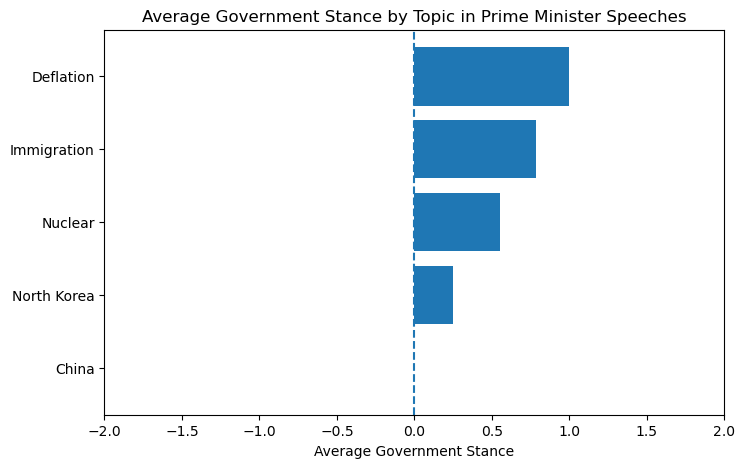

In [228]:
import matplotlib.pyplot as plt

speech_summary = speech_summary.sort_values("Average Government Stance")

plt.figure(figsize=(8,5))

plt.barh(
    speech_summary["Topic"],
    speech_summary["Average Government Stance"]
)

plt.axvline(x=0, linestyle="--")
plt.xlim(-2, 2)

plt.xlabel("Average Government Stance")
plt.title("Average Government Stance by Topic in Prime Minister Speeches")

plt.show()

In [ ]:
topic_dfs = {
    "Immigration": immigration_speech_df,
    "China": china_speech_df,
    "Nuclear": nuclear_speech_df,
    "Deflation": deflation_speech_df,
    "North Korea": north_korea_speech_df
}

In [ ]:
for topic, df in topic_dfs.items():

    text = "\n\n".join(
        df["analysis"].tolist()
    )

    prompt = f"""
Summarize the findings for {topic}.

Include:
- overall sentiment
- dominant frames
- recurring themes

Keep to 4-5 sentences.
    
{text[:12000]}
"""

    summary = llm_ollama(prompt)

    print("="*80)
    print(topic)
    print(summary)

Immigration
Here is a summary of the findings for Immigration:

Overall Sentiment: Not clear (some speeches present a supportive stance towards Immigration, while others do not)

Dominant Frames: Demographic, Humanitarian, Labor Market (with varying degrees of support and opposition)

Recurring Themes: None explicitly discussed in most speeches. However, some speeches mention the importance of addressing refugee and migrant movements, economic development, and cultural exchange.

Notable Sentences:

* Some speeches present a supportive stance towards Immigration by highlighting its demographic implications and the need for humanitarian assistance.
* Others do not explicitly discuss Immigration or present a clear policy position on the issue.
* A few speeches focus on the economic benefits of Immigration, such as job creation and foreign investment.

Scores: 0 (No clear position or policy stance on Immigration is presented), 1 Somewhat supportive (Immigration discussed but no clear stan

## Comparing the Data

In [229]:
print("News")
print(immigration_articles_df["score"].mean())
print(china_articles_df["score"].mean())
print(nuclear_articles_df["score"].mean())
print(deflation_articles_df["score"].mean())
print(north_korea_articles_df["score"].mean())

print("\nSpeeches")
print(immigration_speech_df["score"].mean())
print(china_speech_df["score"].mean())
print(nuclear_speech_df["score"].mean())
print(Deflation_speech_df["score"].mean())
print(north_korea_speech_df["score"].mean())

News
0.05
-0.4
-0.2
-0.2
-1.35

Speeches
0.7857142857142857
0.0
0.55
1.0
0.25


In [232]:
comparison = pd.DataFrame({
    "Topic": [
        "Immigration",
        "China",
        "Nuclear",
        "Deflation",
        "North Korea"
    ],
    "News": [
        immigration_articles_df["score"].mean(),
        china_articles_df["score"].mean(),
        nuclear_articles_df["score"].mean(),
        deflation_articles_df["score"].mean(),
        north_korea_articles_df["score"].mean()
    ],
    "Speeches": [
        immigration_speech_df["score"].mean(),
        china_speech_df["score"].mean(),
        nuclear_speech_df["score"].mean(),
        Deflation_speech_df["score"].mean(),
        north_korea_speech_df["score"].mean()
    ]
})

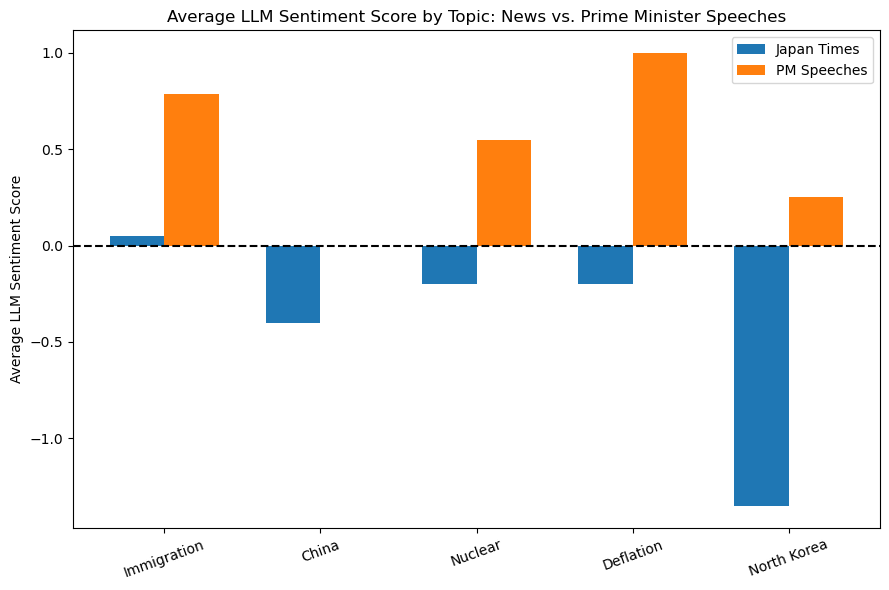

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison = pd.DataFrame({
    "Topic": [
        "Immigration",
        "China",
        "Nuclear",
        "Deflation",
        "North Korea"
    ],
    "News": [
        0.05,
        -0.40,
        -0.20,
        -0.20,
        -1.35
    ],
    "Speeches": [
        0.785714,
        0.00,
        0.55,
        1.00,
        0.25
    ]
})

x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(9,6))

plt.bar(
    x - width/2,
    comparison["News"],
    width,
    label="Japan Times"
)

plt.bar(
    x + width/2,
    comparison["Speeches"],
    width,
    label="PM Speeches"
)

plt.axhline(0, color="black", linestyle="--")

plt.xticks(x, comparison["Topic"], rotation=20)

plt.ylabel("Average LLM Sentiment Score")
plt.title("Average LLM Sentiment Score by Topic: News vs. Prime Minister Speeches")

plt.legend()

plt.tight_layout()
plt.show()